In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:/Users/kashi/OneDrive/Desktop/hotel_bookings.csv")

print("\n========== DATASET LOADED ==========")
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nFirst 5 Records:")
print(df.head())






========== DATASET LOADED ==========
Number of Rows: 119390
Number of Columns: 32

First 5 Records:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  

In [7]:

print("\n========== DATASET INFORMATION ==========")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe().T)



========== DATASET INFORMATION ==========

Column Names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Data Types:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend

In [9]:

print("\n========== MISSING VALUE ANALYSIS ==========")

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0].sort_values(ascending=False))

print("\nPercentage of missing values:")
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
)




print("\n========== DUPLICATE ANALYSIS ==========")

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)


# Remove exact duplicate records

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

print("Remaining duplicate rows:", df.duplicated().sum())
print("\n========== REMOVING UNNECESSARY COLUMN ==========")



if "company" in df.columns:
    df = df.drop(columns=["company"])
    print("'company' column removed.")




print("\n========== HANDLING MISSING VALUES ==========")




if "children" in df.columns:

    children_median = df["children"].median()

    df["children"] = df["children"].fillna(children_median)

    print(
        "Missing 'children' values filled with median:",
        children_median
    )




if "country" in df.columns:

    df["country"] = df["country"].fillna("Unknown")

    print("Missing 'country' values filled with 'Unknown'.")




if "agent" in df.columns:

    df["agent"] = df["agent"].fillna("Unknown")

    print("Missing 'agent' values filled with 'Unknown'.")




categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:

    df[column] = df[column].fillna("Unknown")


print("\nRemaining missing values:")

remaining_missing = df.isnull().sum()

print(
    remaining_missing[remaining_missing > 0]
)



========== MISSING VALUE ANALYSIS ==========
Missing values in each column:
company     112593
agent        16340
country        488
children         4
dtype: int64

Percentage of missing values:
company     94.306893
agent       13.686238
country      0.408744
children     0.003350
dtype: float64

========== DUPLICATE ANALYSIS ==========
Number of duplicate rows: 31994
Dataset shape after removing duplicates: (87396, 32)
Remaining duplicate rows: 0

========== REMOVING UNNECESSARY COLUMN ==========
'company' column removed.

========== HANDLING MISSING VALUES ==========
Missing 'children' values filled with median: 0.0
Missing 'country' values filled with 'Unknown'.
Missing 'agent' values filled with 'Unknown'.

Remaining missing values:
Series([], dtype: int64)


In [11]:
print("\n========== DATA TYPE CORRECTION ==========")

numeric_columns = [

    "is_canceled",
    "lead_time",
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"

]

for column in numeric_columns:

    if column in df.columns:

        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )


print("Numeric data types corrected.")




print("\n========== TEXT DATA CLEANING ==========")

text_columns = df.select_dtypes(
    include=["object"]
).columns

for column in text_columns:

    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
    )


print("Extra spaces removed from categorical columns.")




print("\n========== INVALID ADR CHECK ==========")

negative_adr = (df["adr"] < 0).sum()

print("Negative ADR values:", negative_adr)


if negative_adr > 0:

    # Replace negative ADR with missing value
    df.loc[df["adr"] < 0, "adr"] = np.nan

    # Fill with median
    df["adr"] = df["adr"].fillna(
        df["adr"].median()
    )

    print("Invalid ADR values corrected.")

else:

    print("No negative ADR values found.")



print("\n========== INVALID GUEST VALUE CHECK ==========")

guest_columns = [
    "adults",
    "children",
    "babies"
]

for column in guest_columns:

    if column in df.columns:

        negative_values = (
            df[column] < 0
        ).sum()

        print(
            column,
            "negative values:",
            negative_values
        )

        if negative_values > 0:

            df.loc[
                df[column] < 0,
                column
            ] = np.nan

            df[column] = df[column].fillna(
                df[column].median()
            )




print("\n========== OUTLIER DETECTION ==========")


def detect_outliers(data, column):

    Q1 = data[column].quantile(0.25)

    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR

    upper_limit = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_limit) |
        (data[column] > upper_limit)
    ]

    print("\nColumn:", column)

    print("Q1:", Q1)

    print("Q3:", Q3)

    print("IQR:", IQR)

    print("Lower Limit:", lower_limit)

    print("Upper Limit:", upper_limit)

    print("Number of potential outliers:", len(outliers))

    return outliers


outlier_columns = [

    "adr",
    "lead_time",
    "stays_in_week_nights"

]

for column in outlier_columns:

    if column in df.columns:

        detect_outliers(
            df,
            column
        )



========== DATA TYPE CORRECTION ==========
Numeric data types corrected.

========== TEXT DATA CLEANING ==========
Extra spaces removed from categorical columns.

========== INVALID ADR CHECK ==========
Negative ADR values: 1
Invalid ADR values corrected.

========== INVALID GUEST VALUE CHECK ==========
adults negative values: 0
children negative values: 0
babies negative values: 0

========== OUTLIER DETECTION ==========

Column: adr
Q1: 72.0
Q3: 134.0
IQR: 62.0
Lower Limit: -21.0
Upper Limit: 227.0
Number of potential outliers: 2490

Column: lead_time
Q1: 11.0
Q3: 125.0
IQR: 114.0
Lower Limit: -160.0
Upper Limit: 296.0
Number of potential outliers: 2396

Column: stays_in_week_nights
Q1: 1.0
Q3: 4.0
IQR: 3.0
Lower Limit: -3.5
Upper Limit: 8.5
Number of potential outliers: 1531



========== DATE TRANSFORMATION ==========
Arrival date created successfully.
  arrival_date arrival_date_month
0   2015-07-01               July
1   2015-07-01               July
2   2015-07-01               July
3   2015-07-01               July
4   2015-07-01               July

========== FEATURE ENGINEERING ==========
Total nights feature created.
Total guests feature created.
Cancellation flag created.

Stay Duration Categories:
stay_duration_category
Medium    38156
Short     33580
Long      15660
Name: count, dtype: int64

Lead Time Categories:
lead_time_category
Long          30008
Medium        22744
Very Short    18304
Short         16340
Name: count, dtype: int64

Estimated room value created.

========== FINAL DATA VALIDATION ==========
Final number of rows: 87396
Final number of columns: 39

Remaining duplicate rows: 7

Remaining missing values:
Series([], dtype: int64)

========== CANCELLATION CHECK ==========
Cancellation Counts:
cancellation_flag
0    63371
1    24025


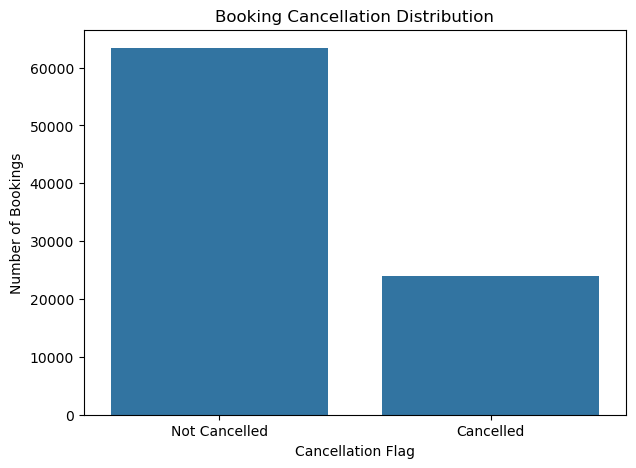

No missing values remain.

DATA CLEANING COMPLETED SUCCESSFULLY

Cleaned dataset saved as: cleaned_hotel_bookings.csv

Final dataset shape: (87396, 39)

Final columns:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'arrival_month_number', 'arrival_date', 'total_nights', 'total_guests', 'cancellation_flag', 'stay_duration_category', 'lead_time_category', 'estimated_room_value']

========== FINAL CLEANED DATA ==========
          hotel  

<Figure size 1200x600 with 0 Axes>

In [13]:



print("\n========== DATE TRANSFORMATION ==========")

month_mapping = {

    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12

}


df["arrival_month_number"] = (
    df["arrival_date_month"]
    .map(month_mapping)
)


df["arrival_date"] = pd.to_datetime(

    dict(

        year=df["arrival_date_year"],

        month=df["arrival_month_number"],

        day=df["arrival_date_day_of_month"]

    ),

    errors="coerce"

)


print("Arrival date created successfully.")

print(
    df[
        [
            "arrival_date",
            "arrival_date_month"
        ]
    ].head()
)


# ============================================================
# STEP 15: CREATE TOTAL NIGHTS
# ============================================================

print("\n========== FEATURE ENGINEERING ==========")

df["total_nights"] = (

    df["stays_in_weekend_nights"]

    +

    df["stays_in_week_nights"]

)


print("Total nights feature created.")


# ============================================================
# STEP 16: CREATE TOTAL GUESTS
# ============================================================

df["total_guests"] = (

    df["adults"]

    +

    df["children"]

    +

    df["babies"]

)


print("Total guests feature created.")


# ============================================================
# STEP 17: CREATE CANCELLATION FLAG
# ============================================================

df["cancellation_flag"] = (

    df["is_canceled"].astype(int)

)


print("Cancellation flag created.")


# ============================================================
# STEP 18: CREATE STAY DURATION CATEGORY
# ============================================================

df["stay_duration_category"] = pd.cut(

    df["total_nights"],

    bins=[
        -1,
        2,
        5,
        np.inf
    ],

    labels=[
        "Short",
        "Medium",
        "Long"
    ]

)


print("\nStay Duration Categories:")

print(
    df["stay_duration_category"]
    .value_counts()
)


# ============================================================
# STEP 19: CREATE LEAD TIME CATEGORY
# ============================================================

df["lead_time_category"] = pd.cut(

    df["lead_time"],

    bins=[
        -1,
        7,
        30,
        90,
        np.inf
    ],

    labels=[
        "Very Short",
        "Short",
        "Medium",
        "Long"
    ]

)


print("\nLead Time Categories:")

print(
    df["lead_time_category"]
    .value_counts()
)


# ============================================================
# STEP 20: CALCULATE ESTIMATED ROOM VALUE
# ============================================================

df["estimated_room_value"] = (

    df["adr"]

    *

    df["total_nights"]

)


print("\nEstimated room value created.")


# ============================================================
# STEP 21: FINAL DATA VALIDATION
# ============================================================

print("\n========== FINAL DATA VALIDATION ==========")


print(
    "Final number of rows:",
    df.shape[0]
)


print(
    "Final number of columns:",
    df.shape[1]
)


print(
    "\nRemaining duplicate rows:",
    df.duplicated().sum()
)


print("\nRemaining missing values:")

final_missing = df.isnull().sum()

print(
    final_missing[
        final_missing > 0
    ]
)


# ============================================================
# STEP 22: CANCELLATION ANALYSIS
# ============================================================

print("\n========== CANCELLATION CHECK ==========")


print(
    "Cancellation Counts:"
)

print(
    df["cancellation_flag"]
    .value_counts()
)


cancellation_rate = (

    df["cancellation_flag"]
    .mean()

    *

    100

)


print(
    "\nOverall Cancellation Rate:",
    round(cancellation_rate, 2),
    "%"
)


# ============================================================
# STEP 23: NUMERICAL SUMMARY OF CLEANED DATA
# ============================================================

print("\n========== CLEANED DATA SUMMARY ==========")

summary_columns = [

    "lead_time",
    "total_nights",
    "total_guests",
    "adr",
    "estimated_room_value"

]


print(
    df[
        summary_columns
    ].describe()
)


# ============================================================
# STEP 24: VISUALIZE CANCELLATION DISTRIBUTION
# ============================================================

print("\n========== CANCELLATION VISUALIZATION ==========")

plt.figure(figsize=(7, 5))

sns.countplot(
    x="cancellation_flag",
    data=df
)

plt.title(
    "Booking Cancellation Distribution"
)

plt.xlabel(
    "Cancellation Flag"
)

plt.ylabel(
    "Number of Bookings"
)

plt.xticks(
    [0, 1],
    ["Not Cancelled", "Cancelled"]
)

plt.show()


# ============================================================
# STEP 25: VISUALIZE MISSING VALUES BEFORE CLEANING
# ============================================================

# This chart is mainly useful for demonstrating
# the data quality problem in your Task 2 report.

plt.figure(figsize=(12, 6))

missing_for_plot = (
    df.isnull()
    .sum()
)

missing_for_plot = (
    missing_for_plot[
        missing_for_plot > 0
    ]
    .sort_values(ascending=False)
)


if len(missing_for_plot) > 0:

    sns.barplot(
        x=missing_for_plot.values,
        y=missing_for_plot.index
    )

    plt.title(
        "Remaining Missing Values After Cleaning"
    )

    plt.xlabel(
        "Number of Missing Values"
    )

    plt.ylabel(
        "Column"
    )

    plt.show()

else:

    print(
        "No missing values remain."
    )


# ============================================================
# STEP 26: SAVE CLEANED DATASET
# ============================================================

output_file = "cleaned_hotel_bookings.csv"

df.to_csv(
    output_file,
    index=False
)


print("\n============================================")
print("DATA CLEANING COMPLETED SUCCESSFULLY")
print("============================================")

print(
    "\nCleaned dataset saved as:",
    output_file
)

print(
    "\nFinal dataset shape:",
    df.shape
)

print(
    "\nFinal columns:"
)

print(
    df.columns.tolist()
)


# ============================================================
# STEP 27: DISPLAY FINAL DATA
# ============================================================

print("\n========== FINAL CLEANED DATA ==========")

print(
    df.head()
)

print("\nTask 2 completed!")